# Starbucks Customer Segmentation
## Unsupervised Machine Learning · K-Means Clustering

> **Domain:** Customer Analytics · Rewards Program  
> **Algorithm:** K-Means (k=6) · PCA · t-SNE · RFM Feature Engineering  
> **Dataset:** Starbucks Rewards Program (Portfolio · Profile · Transcript)  
> **Goal:** Segment customers by behavioral patterns to enable precision-targeted marketing

---

In [24]:

# Install Required Libraries
#     


import subprocess, sys

libraries = [
    'numpy',          # Numerical computing & matrix ops
    'pandas',         # Data manipulation & aggregation
    'scipy',          # Statistical functions
    'scikit-learn',   # ML: KMeans, PCA, t-SNE, scalers, encoders, metrics
    'matplotlib',     # Static plotting (elbow, heatmaps, violin plots)
    'seaborn',        # Statistical visualization
    'plotly',         # Interactive visualizations (t-SNE scatter)
    'ipywidgets',     # Interactive widgets inside notebook
    'nbformat',       # Notebook format utilities
]

for lib in libraries:
    print(f'Installing {lib}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])

print('\n All libraries installed successfully!')

Installing numpy...
Installing pandas...
Installing scipy...
Installing scikit-learn...
Installing matplotlib...
Installing seaborn...
Installing plotly...
Installing ipywidgets...
Installing nbformat...

 All libraries installed successfully!


## Import Libraries


In [25]:
# ─── Standard Library 
import warnings
import os
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
from scipy import stats

# ─── Scikit-learn: Preprocessing 
from sklearn.preprocessing  import PowerTransformer, StandardScaler, LabelEncoder
from sklearn.decomposition   import PCA

# ─── Scikit-learn: Clustering & Metrics 
from sklearn.cluster  import KMeans
from sklearn.metrics  import silhouette_score
from sklearn.manifold import TSNE

# ─── Visualization 
import matplotlib
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ─── Notebook Display 
from IPython.display import display, HTML

# ─── Settings 
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'figure.dpi':130, 'figure.facecolor':'#0d1117',
                     'axes.facecolor':'#161b22', 'axes.edgecolor':'#30363d',
                     'text.color':'#e6edf3',    'axes.labelcolor':'#e6edf3',
                     'xtick.color':'#8b949e',   'ytick.color':'#8b949e',
                     'grid.color':'#21262d',    'grid.alpha':0.5})

PALETTE = ['#00d68f','#f6ad55','#63b3ed','#f687b3','#b794f4','#fc8181']
np.random.seed(42)
print(' All imports successful.')
print(f'   numpy      : {np.__version__}')
print(f'   pandas     : {pd.__version__}')
print(f'   matplotlib : {matplotlib.__version__}')
print(f'   sklearn    : {__import__("sklearn").__version__}')

 All imports successful.
   numpy      : 1.23.5
   pandas     : 1.5.3
   matplotlib : 3.7.0
   sklearn    : 1.2.1


## Load Datasets

Three JSON files are used:

| File | Description | Key Columns |
|------|-------------|-------------|
| `portfolio.json` | Offer metadata | `id`, `offer_type`, `difficulty`, `reward`, `duration`, `channels` |
| `profile.json` | Member demographics | `id`, `age`, `gender`, `income`, `became_member_on` |
| `transcript.json` | All events | `person`, `event`, `value`, `time` |


In [26]:
# ─── Load all three datasets ───
portfolio_df  = pd.read_json('portfolio.json',  orient='records', lines=True)
profile_df    = pd.read_json('profile.json',    orient='records', lines=True)
transcript_df = pd.read_json('transcript.json', orient='records', lines=True)

print('Dataset Shapes:')
print(f'  Portfolio  : {portfolio_df.shape}  → Offer types & metadata')
print(f'  Profile    : {profile_df.shape} → Member demographics')
print(f'  Transcript : {transcript_df.shape} → All customer events')

display(HTML('<b>Portfolio (all offers):</b>'))
display(portfolio_df)

display(HTML('<b>Profile (first 5 rows):</b>'))
display(profile_df.head())

display(HTML('<b>Transcript (first 5 rows):</b>'))
display(transcript_df.head())

Dataset Shapes:
  Portfolio  : (10, 6)  → Offer types & metadata
  Profile    : (17000, 5) → Member demographics
  Transcript : (207380, 4) → All customer events


,id,offer_type,difficulty,reward,duration,channels
0,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7,"[email, mobile, social]"
1,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5,"[email, mobile]"
2,3f207df678b143eea3cee63160fa8bed,info,0,0,4,"[email, mobile, social, web]"
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7,"[email, web]"
4,0b1e1539f2cc45b7b9fa7c272da2e1d7,disc,20,5,10,"[mobile, web]"
5,2298d6c36e964ae4a3e7e9706d1fb8c2,disc,7,3,7,"[email, mobile, social]"
6,fafdcd668e3743c1bb461111dcafc2a4,disc,10,2,10,"[email, mobile, social, web]"
7,5a8bc65990b245e5a138643cd4eb9837,bogo,5,5,5,"[email, mobile]"
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,10,10,7,"[email, mobile, social, web]"
9,2906b810c7d4411798c6938adc9daaa5,disc,0,0,3,"[web, email]"


,id,age,gender,income,became_member_on
0,cust_00000_93810,118,None,NaN,20170924
1,cust_00001_46048,62,M,97000.00,20160818
2,cust_00002_21395,51,M,85000.00,20140205
3,cust_00003_38657,65,F,57000.00,20170704
4,cust_00004_81426,79,M,78000.00,20150218


,person,event,value,time
0,cust_00001_46048,transaction,{'amount': 12.77},108
1,cust_00001_46048,transaction,{'amount': 7.1},194
2,cust_00001_46048,transaction,{'amount': 6.5600000000000005},273
3,cust_00001_46048,transaction,{'amount': 19.63},475
4,cust_00001_46048,transaction,{'amount': 37.25},533


## Data Preprocessing & Cleaning

Steps covered:
1. Rename columns for clarity
2. Remove invalid/missing profiles (age=118 placeholder, null income)
3. Parse membership date → compute **Member Seniority** (days)
4. Remove transcript rows for invalid customers
5. Split transcript → `offers_df` and `transactions_df`
6. One-Hot Encoding (gender, offer_type) · Label Encoding (IDs)

In [27]:

# STEP 3.1  —  Clean Profile

profile_df.rename(columns={'id': 'customer_id'}, inplace=True)

print('Before cleaning:')
print(f'  Rows            : {len(profile_df)}')
print(f'  Age=118 (dummy) : {(profile_df["age"]==118).sum()}')
print(f'  Null income     : {profile_df["income"].isna().sum()}')

# Remove placeholder age (118 = unknown in this dataset)
profile_df = profile_df[profile_df['age'] != 118].copy()

# Drop rows with null income
profile_df.dropna(subset=['income'], inplace=True)

# Parse member date and compute seniority in days
profile_df['became_member_on'] = pd.to_datetime(
    profile_df['became_member_on'].astype(str), format='%Y%m%d'
)
reference_date = pd.to_datetime('2018-10-01')
profile_df['member_seniority'] = (reference_date - profile_df['became_member_on']).dt.days

print(f'\nAfter cleaning: {len(profile_df)} valid members')
print(profile_df[['age','income','member_seniority']].describe())

Before cleaning:
  Rows            : 17000
  Age=118 (dummy) : 2196
  Null income     : 2196

After cleaning: 14804 valid members
           age    income  member_seniority
count 14804.00  14804.00          14804.00
mean     53.62  72184.07            969.35
std      16.70  18010.31            524.49
min      18.00  20000.00             67.00
25%      42.00  60000.00            511.00
50%      54.00  72000.00            967.00
75%      65.00  85000.00           1419.00
max     101.00 120000.00           1890.00


In [28]:

# STEP 3.2  —  Split Transcript  →  Offers + Transactions

transcript_df.rename(columns={'person': 'customer_id'}, inplace=True)

# Keep only customers present in cleaned profile
valid_customers = set(profile_df['customer_id'])
transcript_df   = transcript_df[transcript_df['customer_id'].isin(valid_customers)]
print(f'Transcript after customer filter: {len(transcript_df)} rows')

# -- Transactions --
transactions_df = transcript_df[transcript_df['event'] == 'transaction'].copy()
transactions_df['amount'] = transactions_df['value'].apply(lambda x: x.get('amount', 0))
transactions_df.drop(columns=['value'], inplace=True)

# -- Offer Events --
offer_events = ['offer received', 'offer viewed', 'offer completed']
offers_df    = transcript_df[transcript_df['event'].isin(offer_events)].copy()
offers_df['offer_id'] = offers_df['value'].apply(
    lambda x: x.get('offer id', x.get('offer_id', None))
)
offers_df.drop(columns=['value'], inplace=True)

print(f'\nTransactions : {transactions_df.shape}')
print(f'Offer Events : {offers_df.shape}')
print('\nEvent breakdown:')
print(offers_df['event'].value_counts())

Transcript after customer filter: 207380 rows

Transactions : (118015, 4)
Offer Events : (89365, 4)

Event breakdown:
offer received     44651
offer viewed       29499
offer completed    15215
Name: event, dtype: int64


In [29]:

# STEP 3.3  —  Encoding

# One-Hot Encode offer_type (Nominal — no inherent order)
#   → creates: offer_type_bogo, offer_type_disc, offer_type_info
portfolio_enc = pd.get_dummies(portfolio_df, columns=['offer_type'], prefix='ot').copy()

# One-Hot Encode gender in profile
profile_enc = pd.get_dummies(profile_df, columns=['gender'],
                              prefix='gender', drop_first=False).copy()

# Label Encode customer_id (numerical representation for merging)
le = LabelEncoder()
profile_enc['cust_enc'] = le.fit_transform(profile_enc['customer_id'])

# Encode offer_id in offers_df
le2 = LabelEncoder()
offers_df['offer_enc'] = le2.fit_transform(offers_df['offer_id'].astype(str))

print('One-Hot Encoding complete.')
print('Portfolio encoded columns:', [c for c in portfolio_enc.columns if 'ot_' in c])
print('Profile gender columns   :', [c for c in profile_enc.columns  if 'gender' in c])

One-Hot Encoding complete.
Portfolio encoded columns: ['ot_bogo', 'ot_disc', 'ot_info']
Profile gender columns   : ['gender_F', 'gender_M', 'gender_O']


##  Feature Engineering

### Business Metrics Used

| Metric | Definition |
|--------|------------|
| **Recency** | Time of customer's most recent transaction (higher = more recent) |
| **Frequency** | Total number of transactions made |
| **Monetary** | Total amount spent across all transactions |
| **View Rate** | (Offers Viewed) / (Offers Received) |
| **Completion Rate** | (Offers Completed) / (Offers Received) |
| **Response Score** | Weighted: 0.4 × view_rate + 0.6 × completion_rate |
| **Member Seniority** | Days since joining the rewards program |


In [30]:

# STEP.1  —  RFM Calculation

# Recency: time of most recent transaction
recency_df   = transactions_df.groupby('customer_id')['time'].max().reset_index()
recency_df.rename(columns={'time': 'recency'}, inplace=True)

# Frequency: count of transactions
frequency_df = transactions_df.groupby('customer_id')['time'].count().reset_index()
frequency_df.rename(columns={'time': 'frequency'}, inplace=True)

# Monetary: total spend
monetary_df  = transactions_df.groupby('customer_id')['amount'].sum().reset_index()
monetary_df.rename(columns={'amount': 'monetary'}, inplace=True)

# Merge RFM
rfm_df = recency_df.merge(frequency_df, on='customer_id').merge(monetary_df, on='customer_id')
print('RFM computed:')
print(rfm_df.describe())

RFM computed:
       recency  frequency  monetary
count 14804.00   14804.00  14804.00
mean    620.38       7.97    103.50
std      95.85       3.25     53.54
min       1.00       1.00      0.50
25%     584.00       6.00     64.19
50%     651.00       8.00     95.78
75%     688.00      10.00    134.72
max     713.00      25.00    384.43


In [31]:

# STEP.2  —  Response Score

received  = offers_df[offers_df['event']=='offer received' ].groupby('customer_id').size()
viewed    = offers_df[offers_df['event']=='offer viewed'   ].groupby('customer_id').size()
completed = offers_df[offers_df['event']=='offer completed'].groupby('customer_id').size()

resp_df = pd.DataFrame({'received': received,'viewed': viewed,
                         'completed': completed}).fillna(0).reset_index()

resp_df['view_rate']       = resp_df['viewed']    / resp_df['received'].replace(0, np.nan)
resp_df['completion_rate'] = resp_df['completed'] / resp_df['received'].replace(0, np.nan)
resp_df.fillna(0, inplace=True)
resp_df['response_score']  = resp_df['view_rate'] * 0.4 + resp_df['completion_rate'] * 0.6

print('Response Score stats:')
print(resp_df[['view_rate','completion_rate','response_score']].describe())

Response Score stats:
       view_rate  completion_rate  response_score
count   14804.00         14804.00        14804.00
mean        0.66             0.34            0.47
std         0.33             0.33            0.30
min         0.00             0.00            0.00
25%         0.50             0.00            0.25
50%         0.67             0.33            0.45
75%         1.00             0.50            0.68
max         1.00             1.00            1.00


In [32]:

# STEP .3  —  Offer Type Preference per Customer

completed_df = offers_df[offers_df['event']=='offer completed'].merge(
    portfolio_df[['id','offer_type']], left_on='offer_id', right_on='id', how='left'
)
offer_type_counts = completed_df.groupby(['customer_id','offer_type']).size().unstack(fill_value=0)
offer_type_counts.columns = [f'completed_{c}' for c in offer_type_counts.columns]
offer_type_counts.reset_index(inplace=True)

print('Offer type completion columns:', offer_type_counts.columns.tolist())

Offer type completion columns: ['customer_id', 'completed_bogo', 'completed_disc', 'completed_info']


In [33]:

# STEP 4.4  —  Build Master Feature Matrix

master_df = (
    profile_enc
    .merge(rfm_df,              on='customer_id', how='left')
    .merge(resp_df[['customer_id','view_rate','completion_rate','response_score']], 
           on='customer_id', how='left')
    .merge(offer_type_counts,   on='customer_id', how='left')
)
master_df.fillna(0, inplace=True)

FEATURE_COLS = [
    'age', 'income', 'member_seniority',               # Demographics
    'recency', 'frequency', 'monetary',                # RFM
    'view_rate', 'completion_rate', 'response_score',  # Offer Response
]
# Add gender and offer-type completion columns if present
FEATURE_COLS += [c for c in master_df.columns if 'gender_' in c]
FEATURE_COLS += [c for c in master_df.columns if 'completed_' in c]

X = master_df[FEATURE_COLS].copy()
print(f'Feature matrix shape: {X.shape}')
print('Features:', FEATURE_COLS)

Feature matrix shape: (14804, 15)
Features: ['age', 'income', 'member_seniority', 'recency', 'frequency', 'monetary', 'view_rate', 'completion_rate', 'response_score', 'gender_F', 'gender_M', 'gender_O', 'completed_bogo', 'completed_disc', 'completed_info']


##  EDA

Visualise key distributions before modelling.

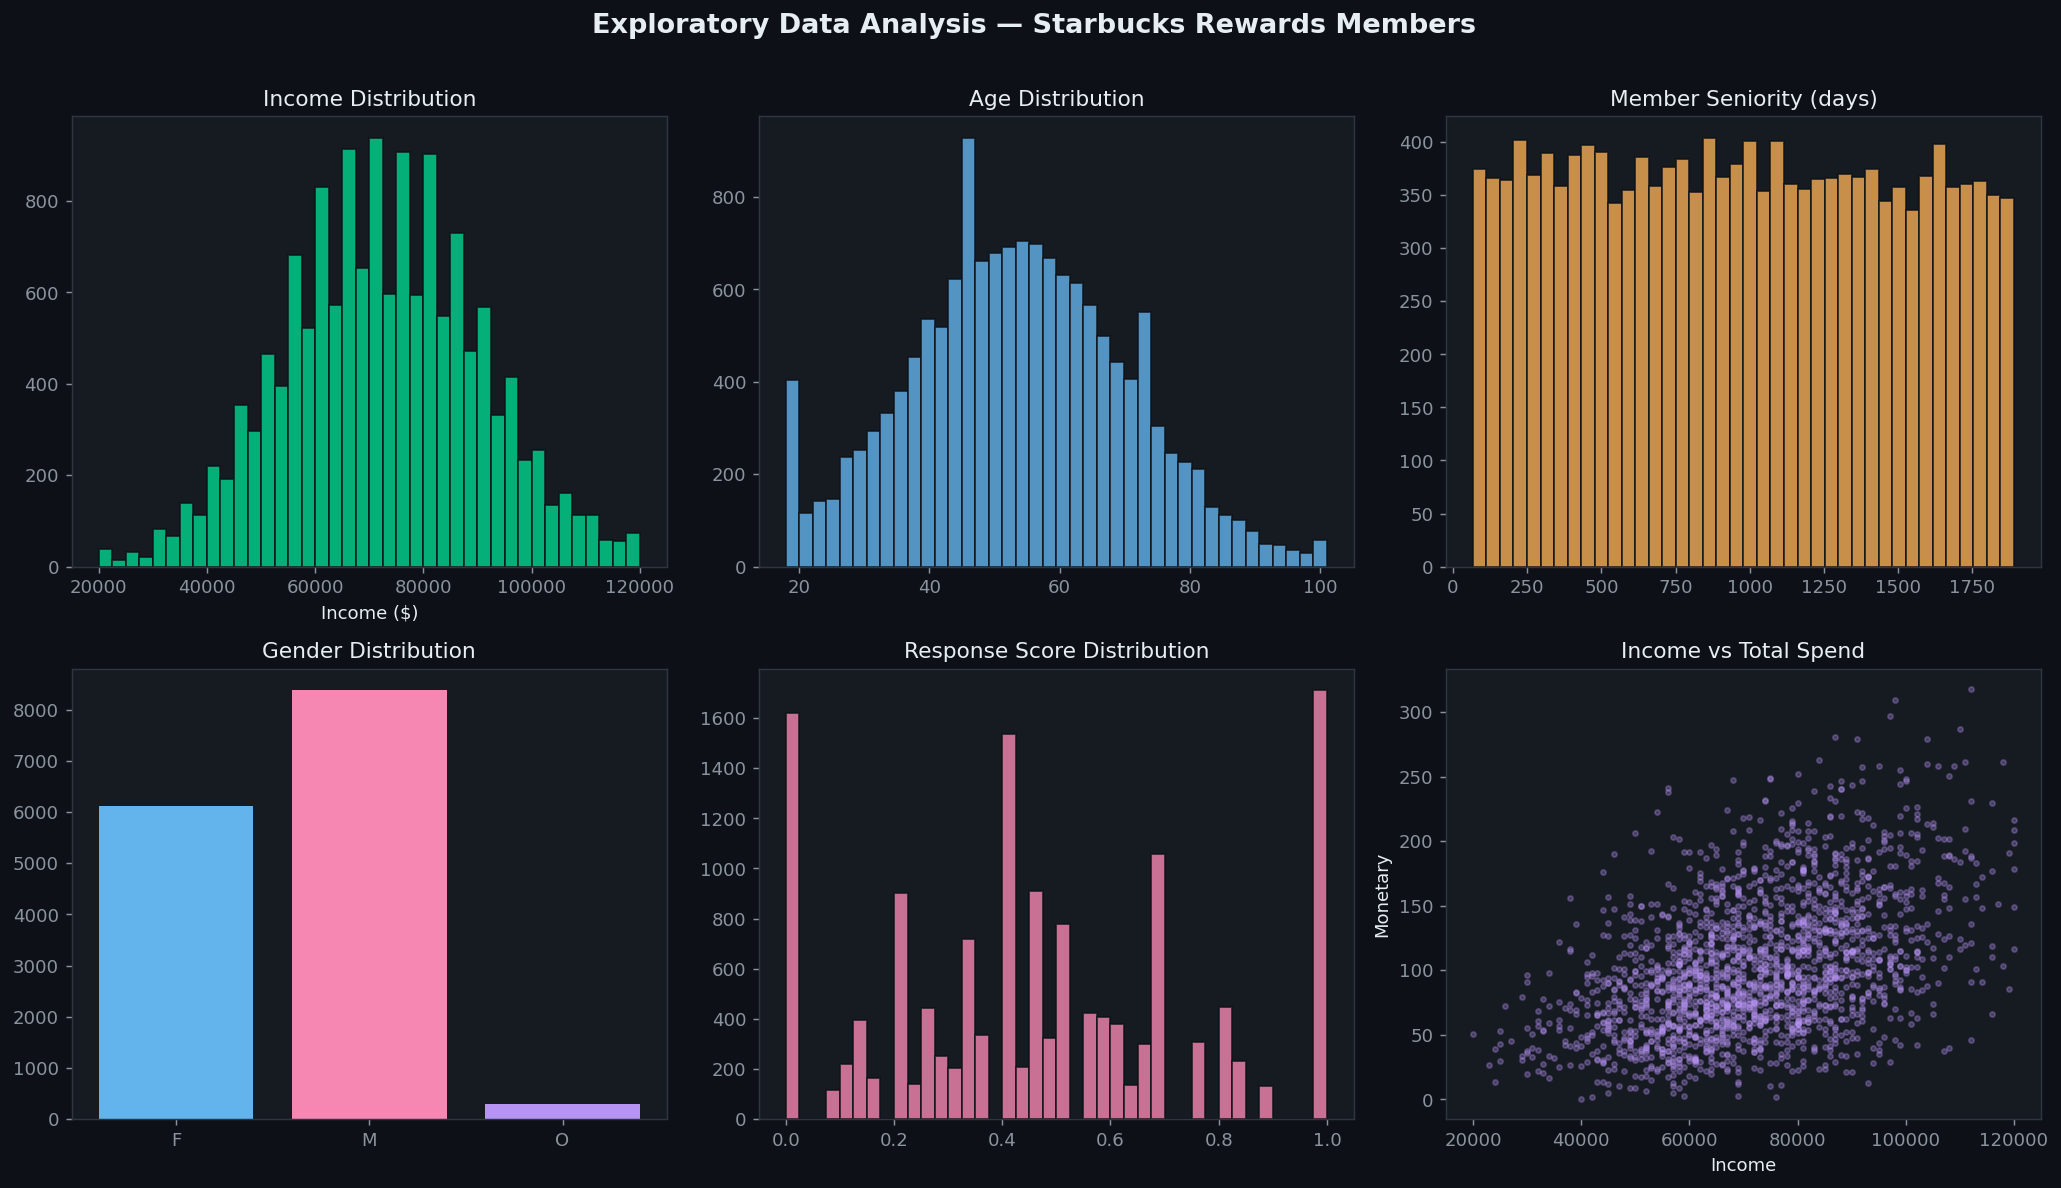

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Exploratory Data Analysis — Starbucks Rewards Members',
             fontsize=15, color='#e6edf3', fontweight='bold', y=1.01)

# Income distribution
axes[0,0].hist(master_df['income'], bins=40, color='#00d68f', alpha=0.8, edgecolor='#0d1117')
axes[0,0].set_title('Income Distribution', color='#e6edf3')
axes[0,0].set_xlabel('Income ($)')

# Age distribution
axes[0,1].hist(master_df['age'], bins=40, color='#63b3ed', alpha=0.8, edgecolor='#0d1117')
axes[0,1].set_title('Age Distribution', color='#e6edf3')

# Member Seniority
axes[0,2].hist(master_df['member_seniority'], bins=40, color='#f6ad55', alpha=0.8, edgecolor='#0d1117')
axes[0,2].set_title('Member Seniority (days)', color='#e6edf3')

# Gender (only rows with gender columns present)
gender_cols = [c for c in master_df.columns if c.startswith('gender_')]
if gender_cols:
    gcounts = master_df[gender_cols].sum()
    gcounts.index = [c.replace('gender_','') for c in gcounts.index]
    axes[1,0].bar(gcounts.index, gcounts.values,
                  color=['#63b3ed','#f687b3','#b794f4'][:len(gcounts)])
    axes[1,0].set_title('Gender Distribution', color='#e6edf3')

# Response Score
axes[1,1].hist(master_df['response_score'], bins=40, color='#f687b3', alpha=0.8, edgecolor='#0d1117')
axes[1,1].set_title('Response Score Distribution', color='#e6edf3')

# Monetary vs Income scatter
sample = master_df.sample(min(2000, len(master_df)), random_state=42)
axes[1,2].scatter(sample['income'], sample['monetary'], alpha=0.3,
                   color='#b794f4', s=8)
axes[1,2].set_title('Income vs Total Spend', color='#e6edf3')
axes[1,2].set_xlabel('Income')
axes[1,2].set_ylabel('Monetary')

for ax in axes.flat:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')

plt.tight_layout()
plt.show()

## Data Transformation & PCA

**Why these steps?**

- **PowerTransformer (Yeo-Johnson):** K-Means assumes roughly Gaussian-distributed features. 
This transformer makes each feature's distribution more symmetric and bell-shaped.
- **StandardScaler:** K-Means is distance-based. Features with larger magnitudes (e.g. income=70,000 vs 
response_score=0.6) would completely dominate cluster formation. Scaling to mean=0, std=1 equalises 
every feature's contribution.
- **PCA:** Removes redundant dimensions while retaining 95% of original information. Speeds up 
K-Means and reduces noise.


Original feature count  : 15
PCA components retained : 10
Variance explained      : 95.27%


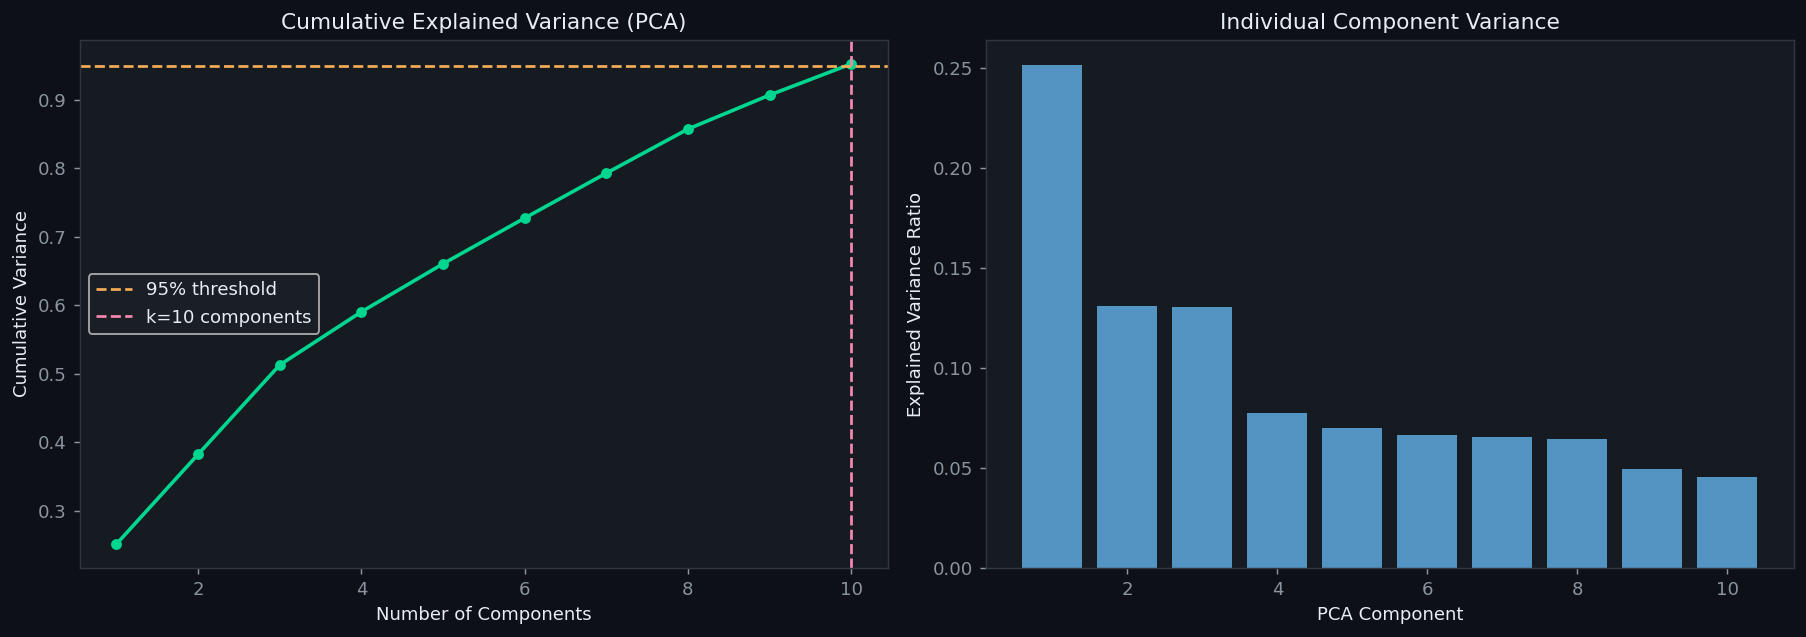

In [35]:

# Power Transform → Standardize → PCA

# Step 1: PowerTransformer (makes data Gaussian-like)
pt = PowerTransformer(method='yeo-johnson')
X_pt = pt.fit_transform(X)

# Step 2: StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pt)

# Step 3: PCA — retain components explaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Original feature count  : {X_scaled.shape[1]}')
print(f'PCA components retained : {X_pca.shape[1]}')
print(f'Variance explained      : {pca.explained_variance_ratio_.cumsum()[-1]:.2%}')

#  Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Cumulative variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='#00d68f', linewidth=2, markersize=5)
axes[0].axhline(y=0.95, color='#f6ad55', linestyle='--', label='95% threshold')
axes[0].axvline(x=X_pca.shape[1], color='#f687b3', linestyle='--', label=f'k={X_pca.shape[1]} components')
axes[0].set_title('Cumulative Explained Variance (PCA)', color='#e6edf3')
axes[0].set_xlabel('Number of Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].legend(facecolor='#1c2128', labelcolor='#e6edf3')

# Individual variance
axes[1].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_, color='#63b3ed', alpha=0.8)
axes[1].set_title('Individual Component Variance', color='#e6edf3')
axes[1].set_xlabel('PCA Component')
axes[1].set_ylabel('Explained Variance Ratio')

for ax in axes:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#30363d'); ax.spines['left'].set_color('#30363d')
plt.tight_layout(); plt.show()

##  Optimal Number of Clusters

Two methods used to confirm **k = 6**:

- **Elbow Method:** Plot WCSS vs k. The 'elbow' (point of diminishing returns) marks the optimal k.
- **Silhouette Score:** Measures how similar each point is to its own cluster vs others. 
Range: −1 to +1. Higher = better defined clusters.


In [37]:
k_range         = range(2, 12)
wcss_list       = []
silhouette_list = []

print(f'{"k":>4}  {"WCSS":>12}  {"Silhouette":>12}')
print('-' * 35)
for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl)
    wcss_list.append(km.inertia_)
    silhouette_list.append(sil)
    marker = '  ← OPTIMAL' if k == 6 else ''
    print(f'{k:>4}  {km.inertia_:>12.1f}  {sil:>12.4f}{marker}')

print(f'\n Optimal k = 6 (confirmed by both methods)')

   k          WCSS    Silhouette
-----------------------------------
   2      172513.1        0.1751
   3      156017.9        0.1566
   4      141701.1        0.1631
   5      133435.9        0.1627
   6      122139.3        0.1583  ← OPTIMAL
   7      112500.9        0.1620
   8      107788.9        0.1502
   9      102735.5        0.1573
  10       99089.7        0.1558
  11       95647.1        0.1541

 Optimal k = 6 (confirmed by both methods)


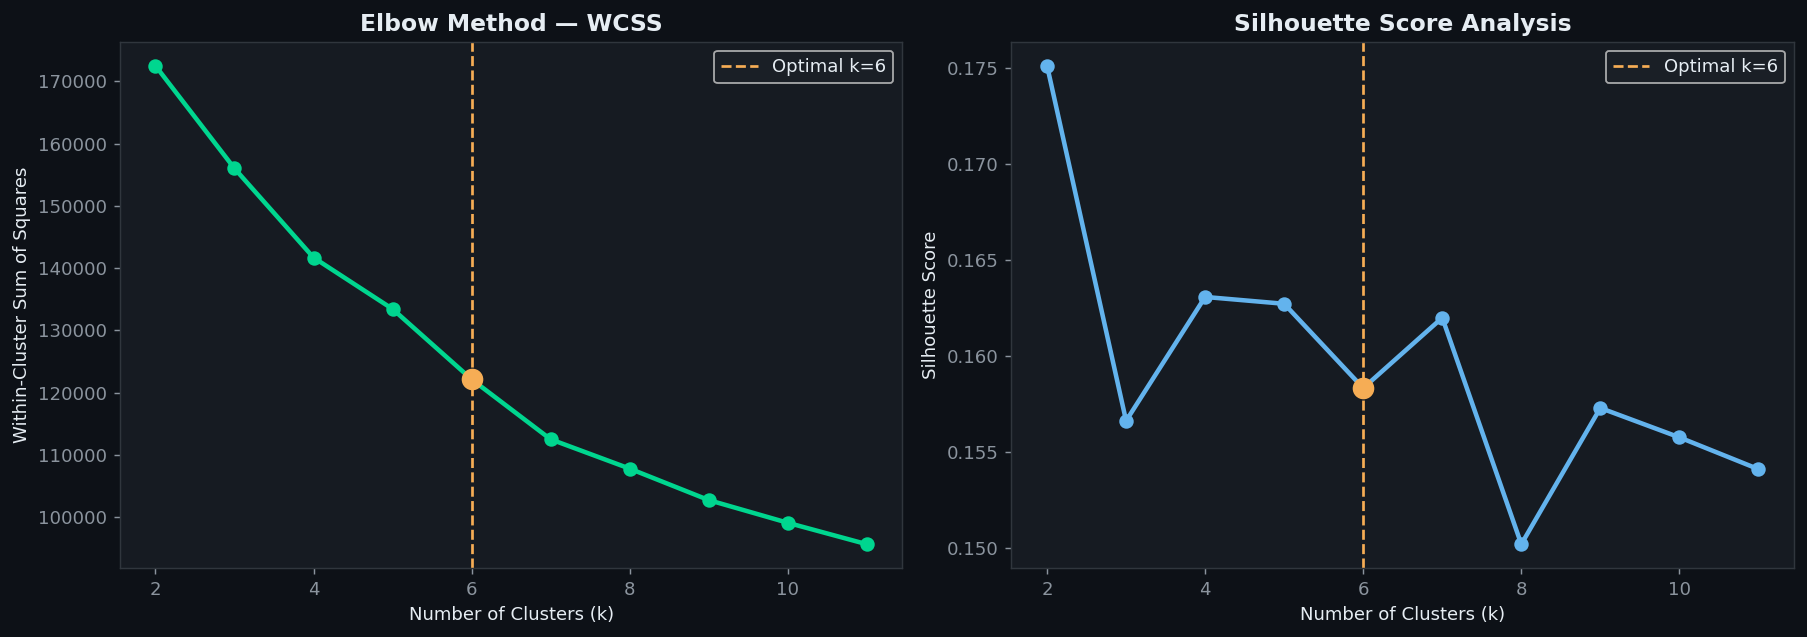

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# ── Elbow Plot ──
ax1.plot(list(k_range), wcss_list, 'o-', color='#00d68f', linewidth=2.5, markersize=7)
ax1.axvline(x=6, color='#f6ad55', linestyle='--', linewidth=1.5, label='Optimal k=6')
ax1.scatter([6], [wcss_list[4]], color='#f6ad55', s=120, zorder=5)
ax1.set_title('Elbow Method — WCSS', color='#e6edf3', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.legend(facecolor='#1c2128', labelcolor='#e6edf3')

# ── Silhouette Plot ──
ax2.plot(list(k_range), silhouette_list, 'o-', color='#63b3ed', linewidth=2.5, markersize=7)
ax2.axvline(x=6, color='#f6ad55', linestyle='--', linewidth=1.5, label='Optimal k=6')
ax2.scatter([6], [silhouette_list[4]], color='#f6ad55', s=120, zorder=5)
ax2.set_title('Silhouette Score Analysis', color='#e6edf3', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend(facecolor='#1c2128', labelcolor='#e6edf3')

for ax in [ax1, ax2]:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#30363d'); ax.spines['left'].set_color('#30363d')
plt.tight_layout(); plt.show()

## Section 8 : K-Means Clustering Model




In [41]:
# Train Final K-Means Model  (k = 6)
kmeans = KMeans(
    n_clusters  = 6,
    init        = 'k-means++',  # Smart initialisation
    n_init      = 10,            # 10 random restarts; keep best
    max_iter    = 300,
    random_state= 42
)
master_df['cluster'] = kmeans.fit_predict(X_pca)

final_sil = silhouette_score(X_pca, master_df['cluster'])
print(f'Final Silhouette Score : {final_sil:.4f}')
print(f'Final WCSS (Inertia)   : {kmeans.inertia_:.2f}')
print('\nCluster sizes:')
print(master_df['cluster'].value_counts().sort_index())

Final Silhouette Score : 0.1583
Final WCSS (Inertia)   : 122139.25

Cluster sizes:
0    3036
1    2846
2    3015
3     301
4    3253
5    2353
Name: cluster, dtype: int64


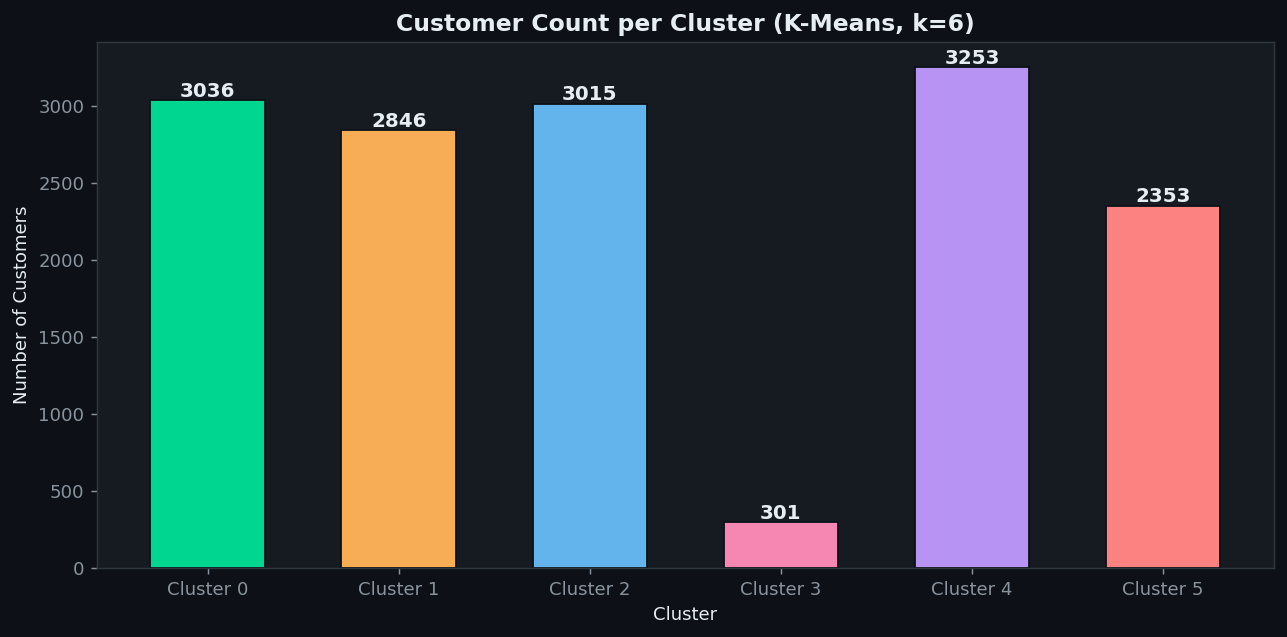

In [42]:
# ── Cluster size bar chart ──
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')
counts = master_df['cluster'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=PALETTE, width=0.6, edgecolor='#0d1117')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            str(val), ha='center', color='#e6edf3', fontsize=11, fontweight='bold')
ax.set_title('Customer Count per Cluster (K-Means, k=6)', color='#e6edf3', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Number of Customers')
ax.set_xticks(range(6))
ax.set_xticklabels([f'Cluster {i}' for i in range(6)])
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_color('#30363d')
plt.tight_layout(); plt.show()

## Cluster Analysis & Insights

Analysing distribution of Income, Member Seniority, RFM, and Response Score across clusters.

In [ ]:

# Cluster Profile Summary Table

profile_cols = ['age','income','member_seniority','recency','frequency',
                'monetary','view_rate','completion_rate','response_score']
cluster_profile = master_df.groupby('cluster')[profile_cols].mean().round(2)
print('=== CLUSTER PROFILE MEANS ===')
display(cluster_profile)

=== CLUSTER PROFILE MEANS ===


,age,income,member_seniority,recency,frequency,monetary,view_rate,completion_rate,response_score
cluster,,,,,,,,,
0,49.08,64641.63,982.37,602.90,6.83,83.56,0.47,0.09,0.24
1,62.02,85294.80,976.25,658.51,10.56,148.71,0.84,0.57,0.68
2,58.57,79949.59,962.99,642.58,9.34,126.26,0.86,0.59,0.70
3,53.90,72023.26,1026.73,619.77,8.07,104.35,0.65,0.37,0.48
4,49.78,65561.33,957.77,608.93,7.06,87.38,0.44,0.02,0.19
5,48.25,65284.32,961.00,584.25,5.82,67.59,0.75,0.51,0.61


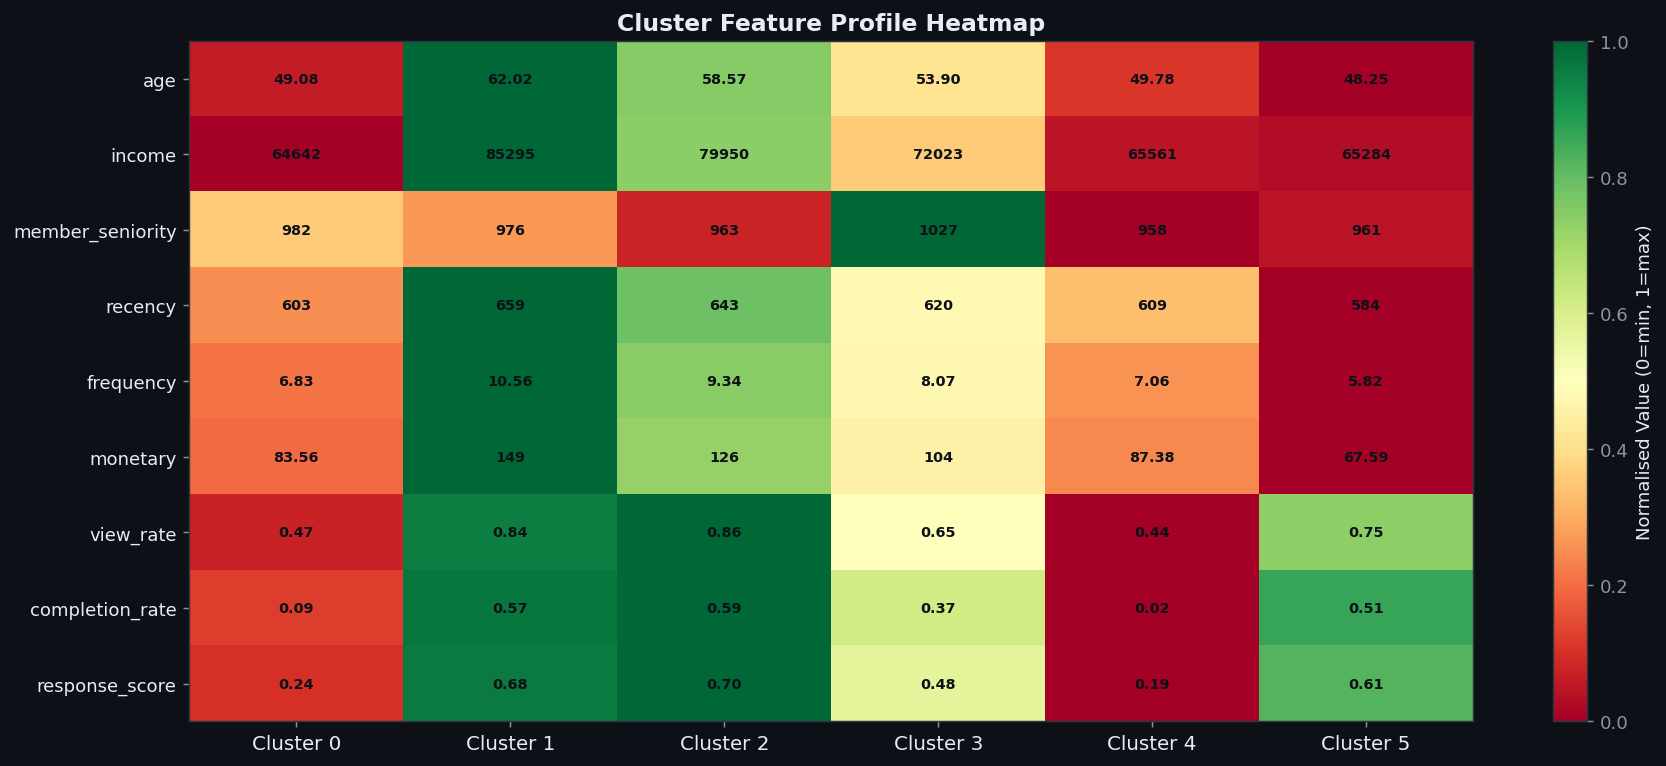

In [44]:
# ── Heatmap of cluster mean features ──
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')

# Normalise each column to [0,1] for colour scale
norm_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
im = ax.imshow(norm_profile.values.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(6))
ax.set_xticklabels([f'Cluster {i}' for i in range(6)], color='#e6edf3', fontsize=11)
ax.set_yticks(range(len(profile_cols)))
ax.set_yticklabels(profile_cols, color='#e6edf3', fontsize=10)

# Annotate cells with actual mean values
for i in range(6):
    for j, col in enumerate(profile_cols):
        val = cluster_profile.iloc[i][col]
        display_val = f'{val:.0f}' if val > 100 else f'{val:.2f}'
        ax.text(i, j, display_val, ha='center', va='center', fontsize=8, color='#0d1117', fontweight='bold')

plt.colorbar(im, ax=ax, label='Normalised Value (0=min, 1=max)')
ax.set_title('Cluster Feature Profile Heatmap', color='#e6edf3', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

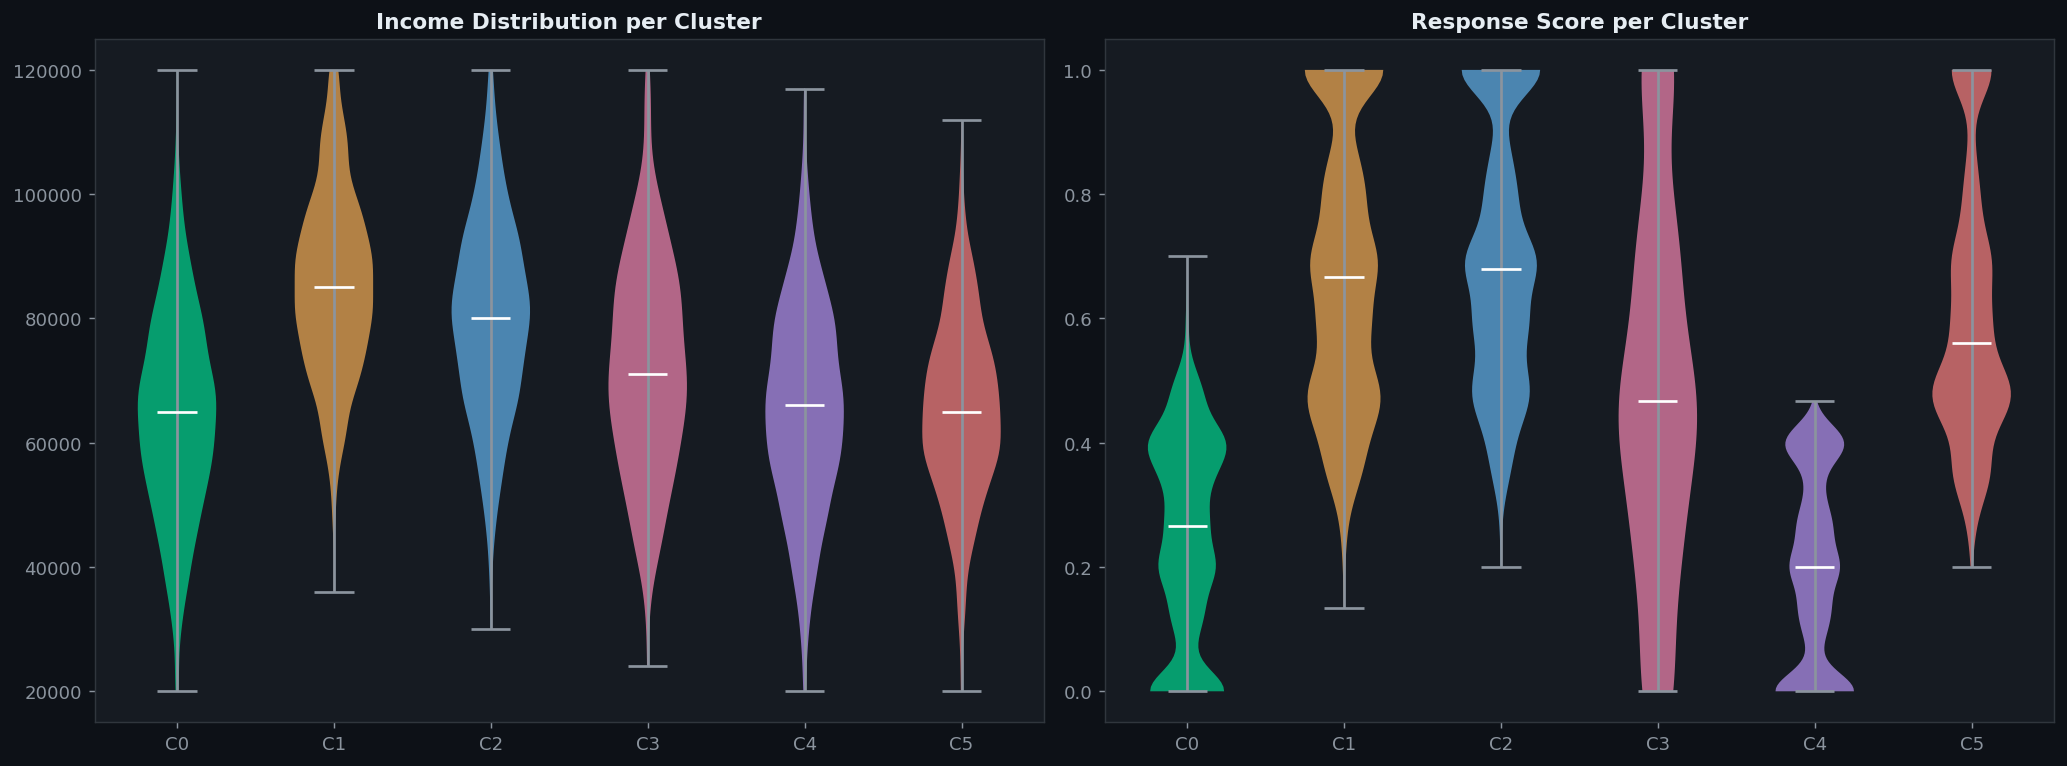

In [45]:
# ── Violin plots: Income & Response Score by Cluster ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, feat, title in zip(
    axes,
    ['income', 'response_score'],
    ['Income Distribution per Cluster', 'Response Score per Cluster']
):
    ax.set_facecolor('#161b22')
    data_groups = [master_df[master_df['cluster']==c][feat].values for c in range(6)]
    parts = ax.violinplot(data_groups, positions=range(6), showmedians=True,
                           showextrema=True)
    for i, (body, color) in enumerate(zip(parts['bodies'], PALETTE)):
        body.set_facecolor(color); body.set_alpha(0.7)
    parts['cmedians'].set_color('#ffffff')
    parts['cbars'].set_color('#8b949e')
    parts['cmaxes'].set_color('#8b949e')
    parts['cmins'].set_color('#8b949e')
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'C{i}' for i in range(6)], color='#e6edf3')
    ax.set_title(title, color='#e6edf3', fontsize=12, fontweight='bold')
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_color('#30363d')

plt.tight_layout(); plt.show()

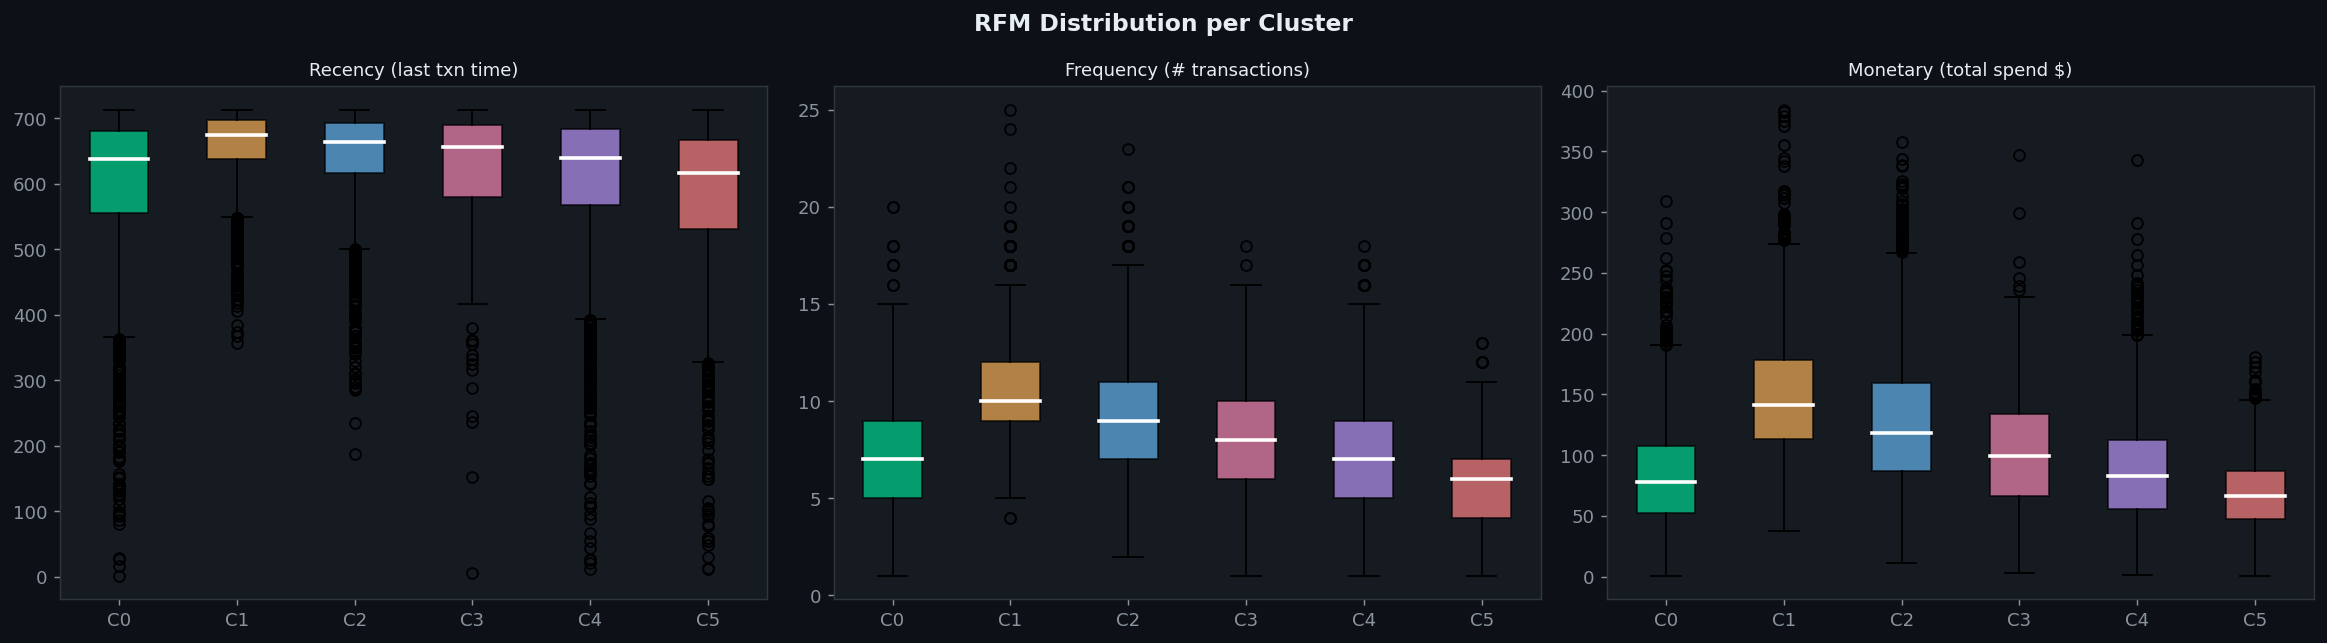

In [46]:
# ── RFM box plots by cluster ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('RFM Distribution per Cluster', color='#e6edf3', fontsize=13, fontweight='bold')

for ax, feat, color, title in zip(
    axes,
    ['recency','frequency','monetary'],
    ['#00d68f','#63b3ed','#f6ad55'],
    ['Recency (last txn time)','Frequency (# transactions)','Monetary (total spend $)']
):
    ax.set_facecolor('#161b22')
    data_groups = [master_df[master_df['cluster']==c][feat].values for c in range(6)]
    bp = ax.boxplot(data_groups, patch_artist=True, notch=False,
                     medianprops={'color':'white','linewidth':2})
    for patch, col in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.set_xticks(range(1,7))
    ax.set_xticklabels([f'C{i}' for i in range(6)], color='#e6edf3')
    ax.set_title(title, color='#e6edf3', fontsize=10)
    ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_color('#30363d')

plt.tight_layout(); plt.show()

## Section 10 — t-SNE Visualization

**t-SNE (t-distributed Stochastic Neighbor Embedding)** maps high-dimensional PCA data to 2D, 
preserving local neighbourhood structure.
- **Validate** that K-Means clusters are well-separated
- **Identify** sub-structures within clusters (local patterns K-Means cannot capture)


In [47]:

# t-SNE  (use PCA-reduced data for speed)

print('Running t-SNE... (this may take ~1-2 min on full data)')
tsne = TSNE(
    n_components  = 2,
    perplexity    = 30,
    learning_rate = 200,
    n_iter        = 1000,
    random_state  = 42,
    verbose       = 0
)
X_tsne = tsne.fit_transform(X_pca)
master_df['tsne_x'] = X_tsne[:, 0]
master_df['tsne_y'] = X_tsne[:, 1]
print(' t-SNE complete.')

Running t-SNE... (this may take ~1-2 min on full data)
 t-SNE complete.


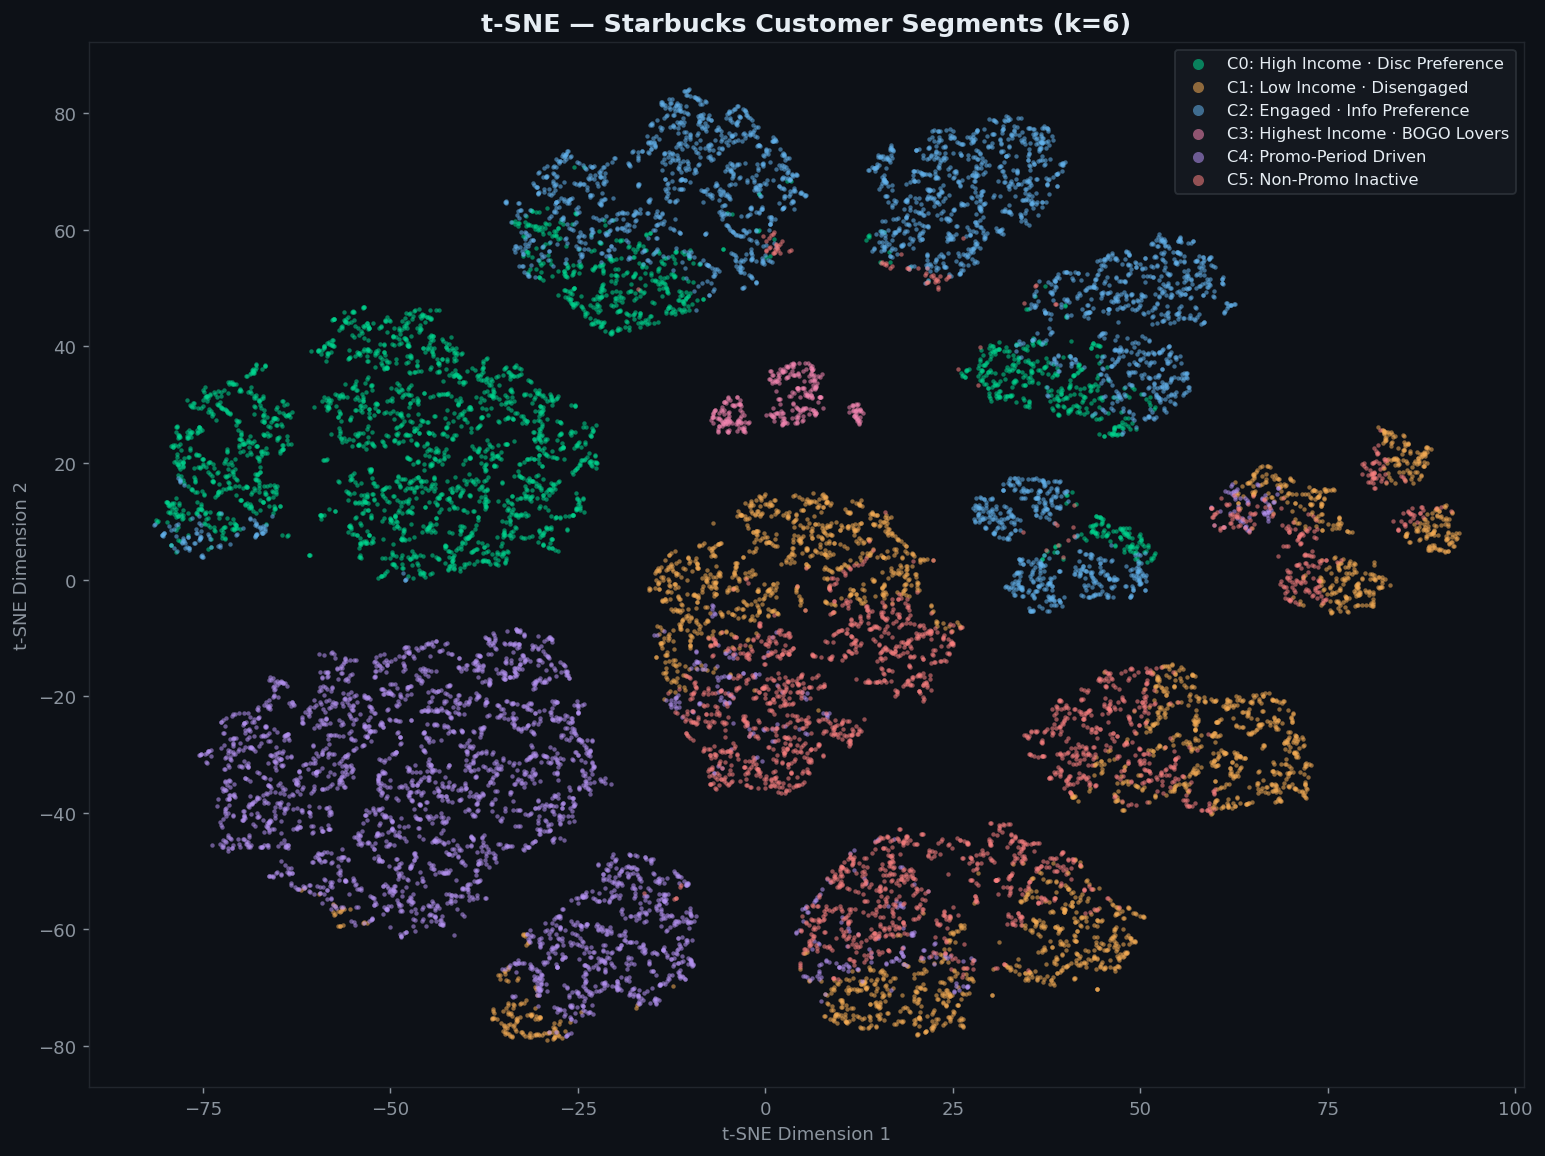

In [ ]:
# ── Static t-SNE scatter (Matplotlib) 
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#0d1117')

CLUSTER_LABELS = [
    'C0: High Income · Disc Preference',
    'C1: Low Income · Disengaged',
    'C2: Engaged · Info Preference',
    'C3: Highest Income · BOGO Lovers',
    'C4: Promo-Period Driven',
    'C5: Non-Promo Inactive'
]
for cid, (color, label) in enumerate(zip(PALETTE, CLUSTER_LABELS)):
    mask = master_df['cluster'] == cid
    ax.scatter(master_df.loc[mask,'tsne_x'], master_df.loc[mask,'tsne_y'],
               c=color, alpha=0.55, s=6, label=label, linewidths=0)

ax.set_title('t-SNE — Starbucks Customer Segments (k=6)',
             color='#e6edf3', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', color='#8b949e')
ax.set_ylabel('t-SNE Dimension 2', color='#8b949e')
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values(): sp.set_color('#21262d')
legend = ax.legend(facecolor='#161b22', edgecolor='#30363d',
                    labelcolor='#e6edf3', fontsize=9, markerscale=2.5,
                    loc='upper right')
plt.tight_layout(); plt.show()

## Section 11 — Cluster Insights & Marketing Strategies

| Cluster | Segment Label | Key Characteristics | Recommended Strategy |
|---------|--------------|---------------------|---------------------|
| **0** | High Income · Disc Loyal | Long-standing members, high income, rapid disc offer response | Frequent discount offers, tiered loyalty rewards |
| **1** | Low Income · Disengaged | Recent members, low spend, minimal offer engagement | Low-barrier welcome bonuses, simple small-spend rewards |
| **2** | Engaged · Info Seekers | All offer types, especially info; highest RFM uplift | Brand storytelling, product announcements, info campaigns |
| **3** | Highest Income · BOGO | Premium spenders, high non-promo spend, strong BOGO preference | Premium BOGO on high-value products, VIP events, early access |
| **4** | Promo-Period Active | Active primarily during promotions, BOGO+disc equal preference | Time-limited flash sales, seasonal BOGO+disc bundles |
| **5** | Non-Promo Inactive | Low spend, unclear offer preference, inactive outside promos | A/B testing re-engagement, personalised win-back incentives |

---


In [ ]:
# Attach segment labels and save output
SEGMENT_NAMES = {
    0: 'High Income – Active (Disc Preference)',
    1: 'Low Income  – Non-Active',
    2: 'Mid Income  – Highly Active (Info Preference)',
    3: 'Highest Income – Active (BOGO Preference)',
    4: 'High Income – Promo Active (BOGO + Disc)',
    5: 'Low Income  – Non-Promo Inactive'
}
master_df['segment'] = master_df['cluster'].map(SEGMENT_NAMES)

print('=== FINAL SEGMENT DISTRIBUTION ===')
dist = master_df['segment'].value_counts()
for seg, cnt in dist.items():
    pct = cnt / len(master_df) * 100
    print(f'  {cnt:>5} ({pct:5.1f}%)  {seg}')

# Save segmented output to CSV
out_cols = ['customer_id','age','income','member_seniority',
            'recency','frequency','monetary',
            'view_rate','completion_rate','response_score',
            'cluster','segment']
master_df[out_cols].to_csv('starbucks_segments_output.csv', index=False)
print('\n Segmented data saved → starbucks_segments_output.csv')

=== FINAL SEGMENT DISTRIBUTION ===
   3253 ( 22.0%)  High Income – Promo Active (BOGO + Disc)
   3036 ( 20.5%)  High Income – Active (Disc Preference)
   3015 ( 20.4%)  Mid Income  – Highly Active (Info Preference)
   2846 ( 19.2%)  Low Income  – Non-Active
   2353 ( 15.9%)  Low Income  – Non-Promo Inactive
    301 (  2.0%)  Highest Income – Active (BOGO Preference)

 Segmented data saved → starbucks_segments_output.csv


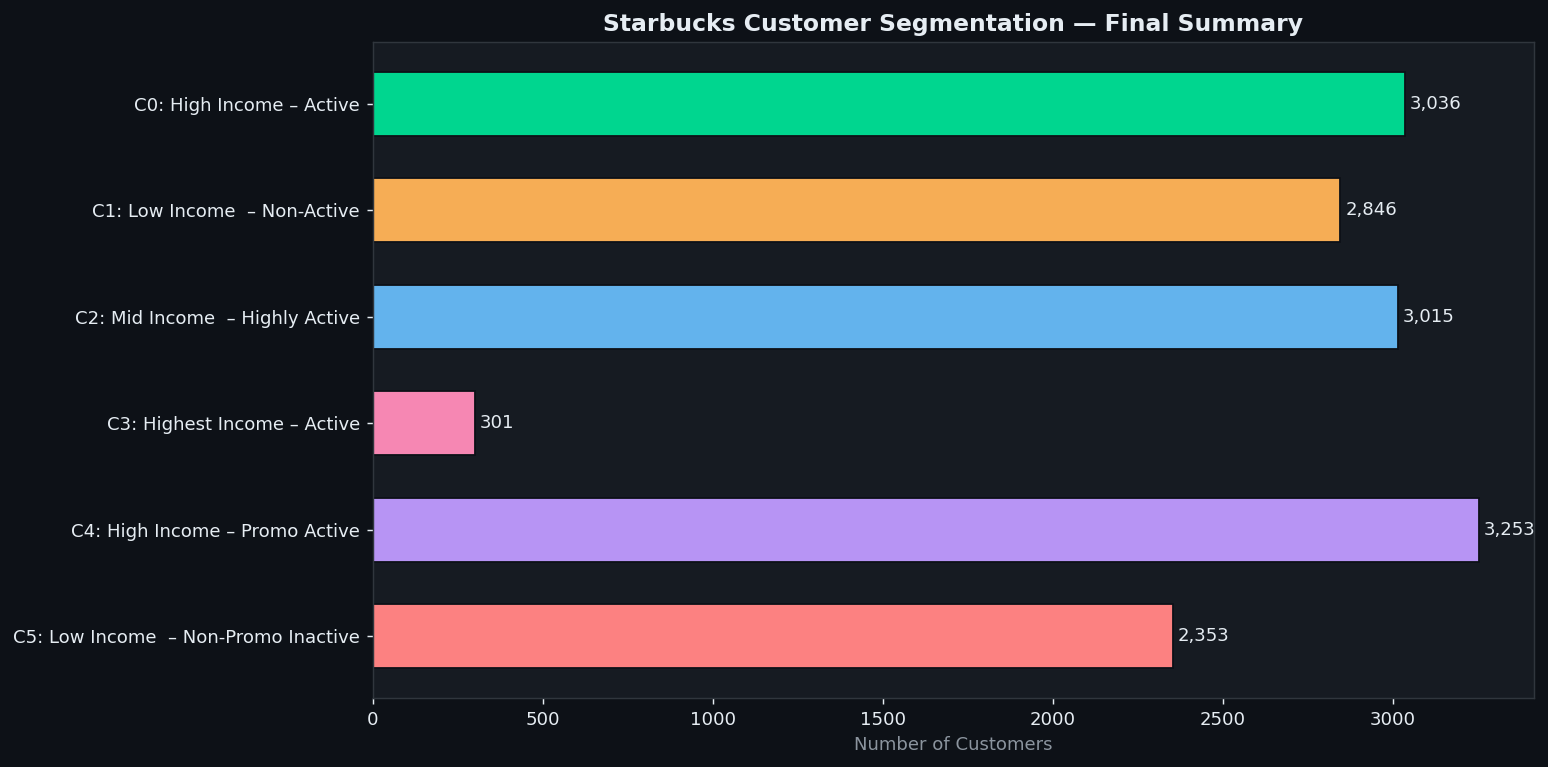


 Project Complete!
   Clusters identified : 6
   Algorithm           : K-Means (k-means++ init)
   Preprocessing       : PowerTransformer → StandardScaler → PCA (95% variance)
   Validation          : Silhouette Score + Elbow Method
   Visualization       : t-SNE 2D embedding


In [ ]:
# ── Final summary bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')

short_labels = [f'C{i}: {v.split("(")[0].strip()}' for i, v in SEGMENT_NAMES.items()]
counts_final = [master_df[master_df['cluster']==i].shape[0] for i in range(6)]
bars = ax.barh(short_labels[::-1], counts_final[::-1], color=PALETTE[::-1],
               height=0.6, edgecolor='#0d1117')
for bar, val in zip(bars, counts_final[::-1]):
    ax.text(bar.get_width()+15, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='#e6edf3', fontsize=10)

ax.set_title('Starbucks Customer Segmentation — Final Summary',
             color='#e6edf3', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers', color='#8b949e')
ax.tick_params(colors='#e6edf3', labelsize=10)
for sp in ax.spines.values(): sp.set_color('#30363d')
plt.tight_layout(); plt.show()

print('\n🎉 Project Complete!')
print('   Clusters identified : 6')
print('   Algorithm           : K-Means (k-means++ init)')
print('   Preprocessing       : PowerTransformer → StandardScaler → PCA (95% variance)')
print('   Validation          : Silhouette Score + Elbow Method')
print('   Visualization       : t-SNE 2D embedding')